# Classification of ECG Report into Five Categories as COVID-19, MI, MI History, Abnormal or Normal Heartbeat

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

In [6]:
data_path = "/content/drive/MyDrive/ECG Images"

In [7]:
data_path

'/content/drive/MyDrive/ECG Images'

In [8]:
covid_images_count = len(os.listdir(os.path.join(data_path,'COVID-19')))
mi_images_count = len(os.listdir(os.path.join(data_path,'MI_Images')))
mi_history_images_count = len(os.listdir(os.path.join(data_path,'MI_History')))
abnormal_images_count = len(os.listdir(os.path.join(data_path,'Abnormal_Heartbeats')))
normal_images_count = len(os.listdir(os.path.join(data_path,'Normal_Heartbeats')))

In [9]:
print('Covid-19_ECG_Images:',covid_images_count)
print('MI_ECG_Images:',mi_images_count)
print('MI_History_ECG_Images:',mi_history_images_count)
print('Abnormal_Heartbeat_ECG_Images:',abnormal_images_count)
print('Normal_Heartbeat_ECG_Images:',normal_images_count)

Covid-19_ECG_Images: 251
MI_ECG_Images: 74
MI_History_ECG_Images: 203
Abnormal_Heartbeat_ECG_Images: 546
Normal_Heartbeat_ECG_Images: 859


In [10]:
labels = ['COVID-19', 'MI', 'MI Hisory', 'Abnormal Heartbeats', 'Normal Heartbeats']
count = [covid_images_count,mi_images_count,mi_history_images_count,abnormal_images_count,normal_images_count]

In [11]:
labels

['COVID-19', 'MI', 'MI Hisory', 'Abnormal Heartbeats', 'Normal Heartbeats']

In [12]:
count

[251, 74, 203, 546, 859]

In [82]:
!pip install plotly

In [13]:
import plotly.express as px

In [14]:
fig = px.bar(x=labels, y=count)
fig.update_layout(xaxis_title="ImageType", yaxis_title="Counts of the Images",
                  title="Distribution of Images in Different Categories of ECG",
                  width=1000, height=550)
fig.show()

In [15]:
fig_1 = px.pie(names=labels, values = count)
fig_1.update_layout(title = "Distribution of ECG Images Across Different Categories",height = 550, width = 1000)
fig_1.show()

In [16]:
covid_path = os.path.join(data_path, 'COVID-19')
mi_images_path = os.path.join(data_path,'MI_Images')
mi_history_images_path = os.path.join(data_path, 'MI_History')
abnormal_images_path = os.path.join(data_path,'Abnormal_Heartbeats')
normal_images_path = os.path.join(data_path,'Normal_Heartbeats')

In [17]:
normal_images_path

'/content/drive/MyDrive/ECG Images/Normal_Heartbeats'

In [18]:
covid_files = os.listdir(covid_path)
mi_files = os.listdir(mi_images_path)
mi_history_files = os.listdir(mi_history_images_path)
abnormal_files = os.listdir(abnormal_images_path)
normal_files = os.listdir(normal_images_path)

In [19]:
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

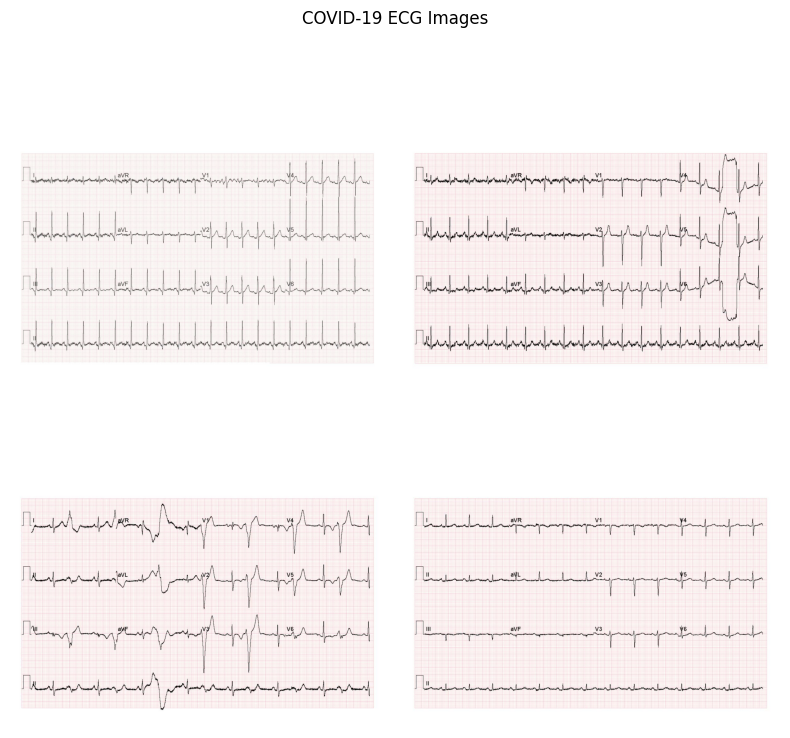

In [20]:
fig,axes = plt.subplots(2,2,figsize = (8,8))
fig.suptitle('COVID-19 ECG Images')
axes = axes.ravel()

for i,image_file in enumerate(covid_files[:4]):
    image_path = os.path.join(covid_path,image_file)
    image = cv2.imread(image_path)
    image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    axes[i].imshow(image)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

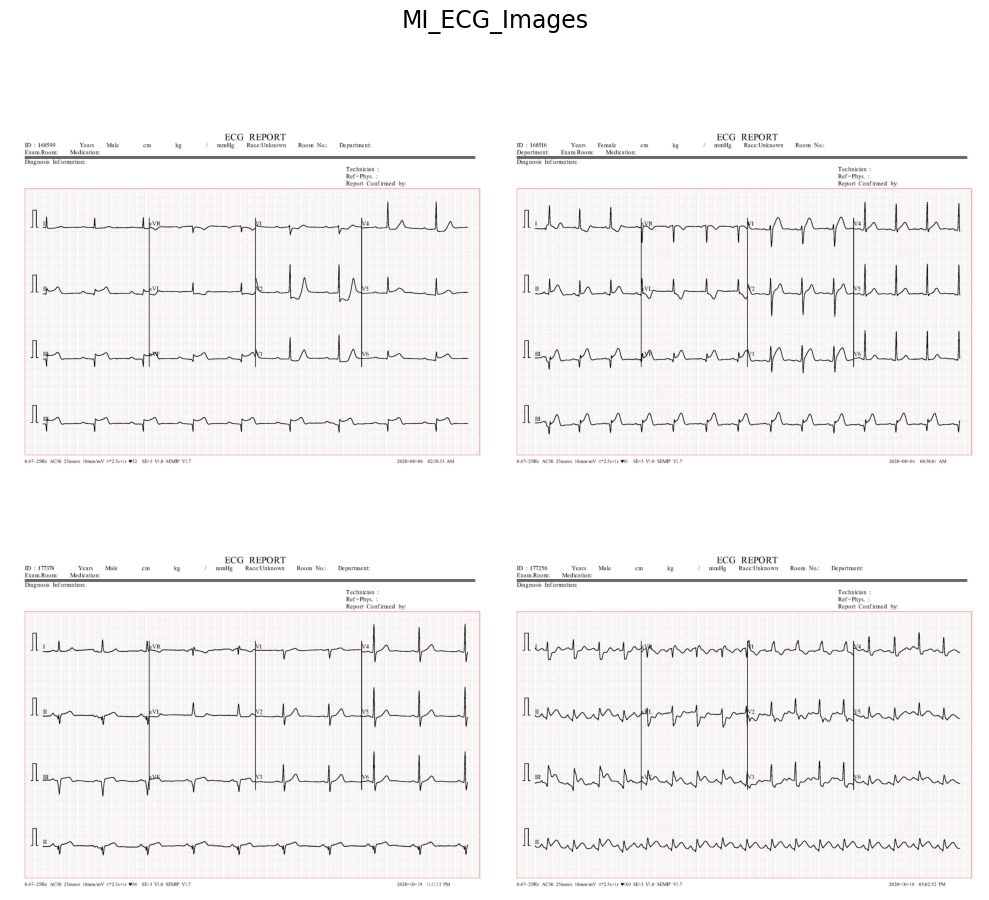

In [21]:
fig,axes = plt.subplots(2,2,figsize=(10,10))
fig.suptitle("MI_ECG_Images",fontsize=17)
axes = axes.ravel()

for i,image_file in enumerate(mi_files[:4]):
    image_path = os.path.join(mi_images_path,image_file)
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    axes[i].imshow(image)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

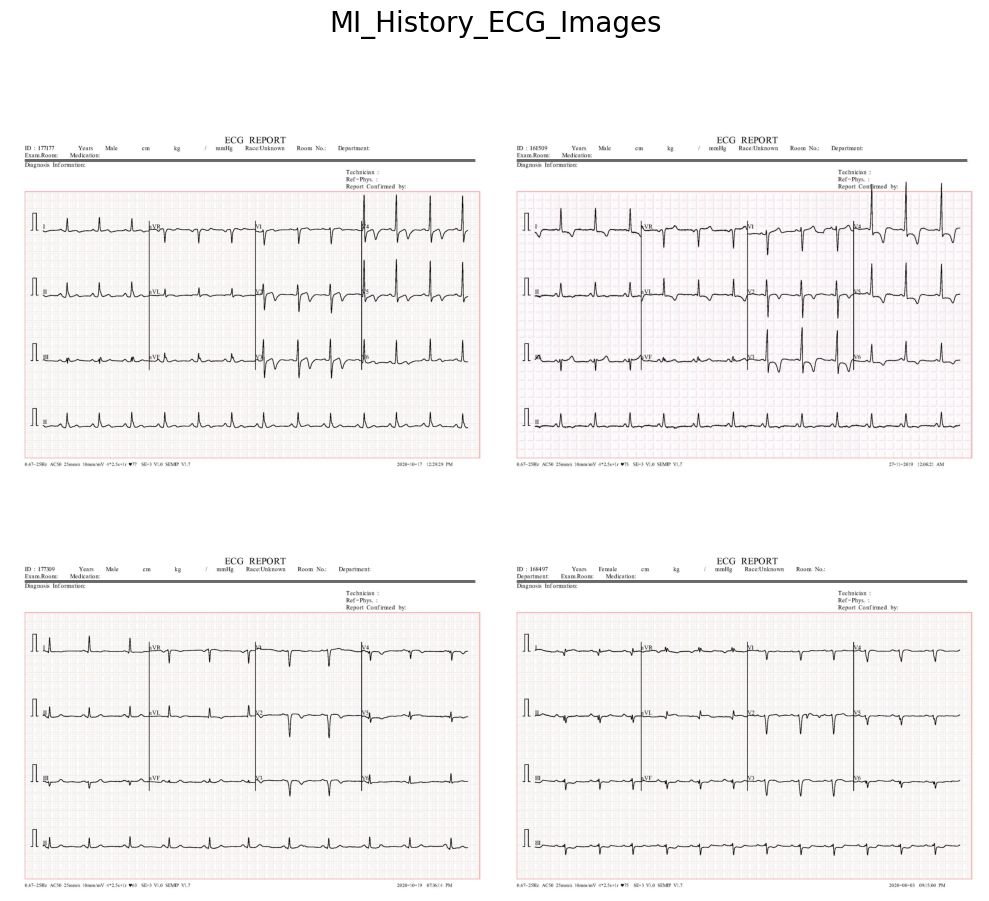

In [22]:
fig,axes = plt.subplots(2,2,figsize = (10,10))
fig.suptitle("MI_History_ECG_Images", fontsize=20)
axes = axes.ravel()

for i,image_file in enumerate(mi_history_files[:4]):
    image_path = os.path.join(mi_history_images_path,image_file)
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    axes[i].imshow(image)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

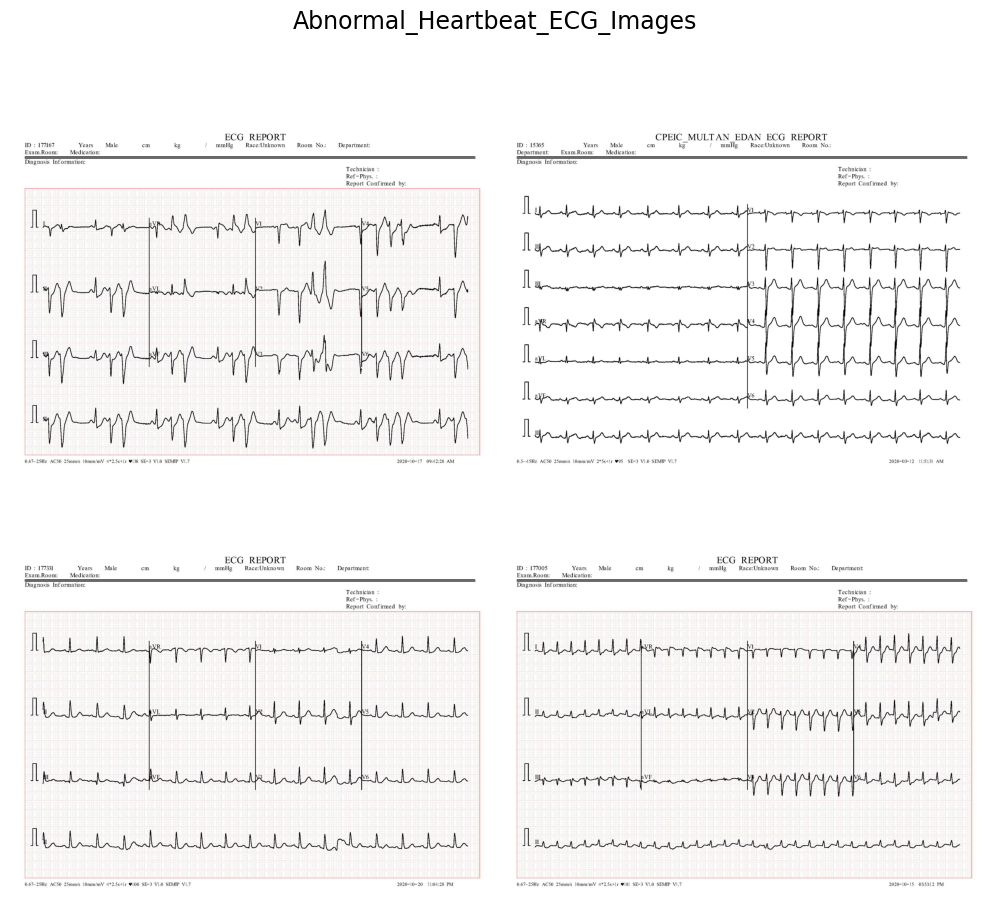

In [23]:
fig,axes = plt.subplots(2,2,figsize = (10,10))
fig.suptitle("Abnormal_Heartbeat_ECG_Images", fontsize=17)
axes = axes.ravel()

for i,image_file in enumerate(abnormal_files[:4]):
    image_path = os.path.join(abnormal_images_path,image_file)
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    axes[i].imshow(image)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

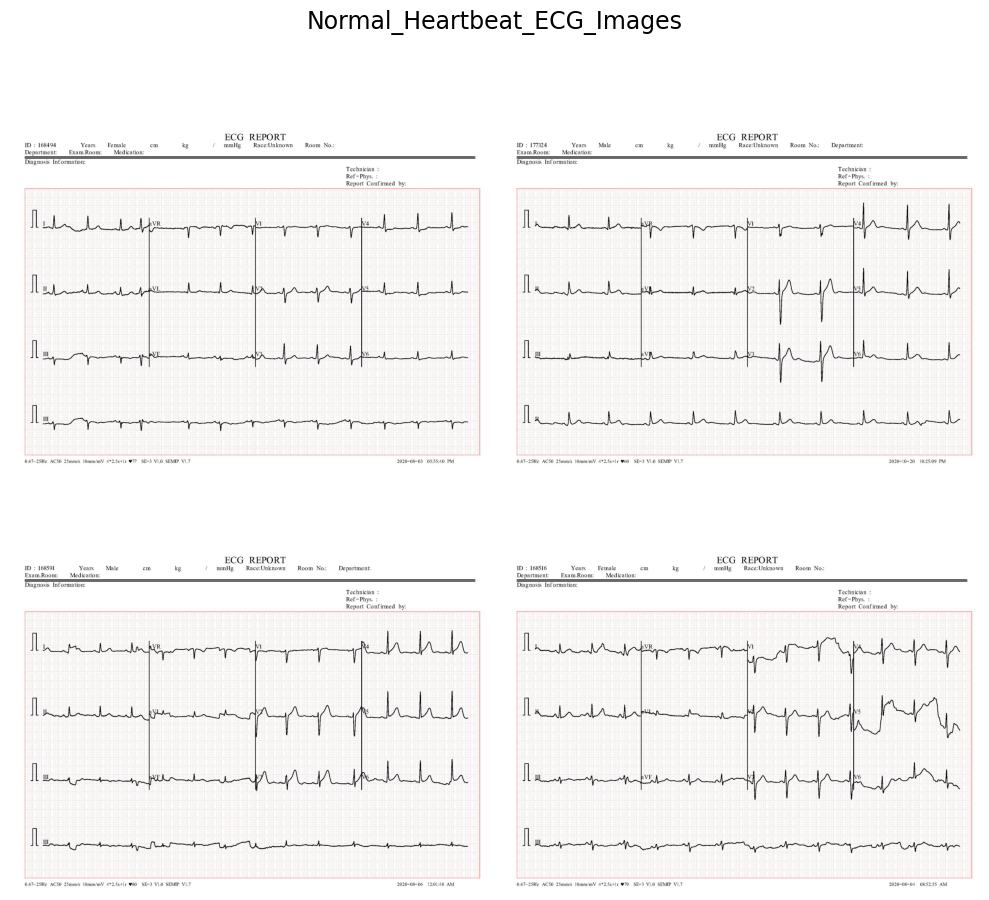

In [24]:
fig,axes = plt.subplots(2,2,figsize = (10,10))
fig.suptitle("Normal_Heartbeat_ECG_Images", fontsize=17)
axes = axes.ravel()

for i,image_file in enumerate(normal_files[:4]):
    image_path = os.path.join(normal_images_path,image_file)
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    axes[i].imshow(image)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# Preprocessing Images

In [25]:
import numpy as np

In [26]:
def load_and_preprocess(image_folder):
    image_files = os.listdir(image_folder)
    images = []

    for image_file in image_files:
        image_path = os.path.join(image_folder,image_file)
        image = cv2.imread(image_path)
        if image is not None:
            image = cv2.resize(image, (128,128))
            images.append(image)
    return images

In [27]:
def load_and_preprocess_images(image_folder):
    image_files = os.listdir(image_folder)
    images = []
    for image_file in image_files:
        image_path = os.path.join(image_folder, image_file)
        image = cv2.imread(image_path)
        if image is not None:
            image = cv2.resize(image,(128,128))
            images.append(image)
    return images

In [29]:
covid_path = os.path.join(data_path, 'COVID-19')
mi_images_path = os.path.join(data_path,'MI_Images')
mi_history_images_path = os.path.join(data_path, 'MI_History')
abnormal_images_path = os.path.join(data_path,'Abnormal_Heartbeats')
normal_images_path = os.path.join(data_path,'Normal_Heartbeats')

In [30]:
covid_files = load_and_preprocess(covid_path)
mi_files = load_and_preprocess(mi_images_path)
mi_history_files = load_and_preprocess(mi_history_images_path)
abnormal_files = load_and_preprocess(abnormal_images_path)
normal_files = load_and_preprocess(normal_images_path)

In [31]:
covid_files = np.array(covid_files).reshape(-1,128,128,3)
mi_files = np.array(mi_files).reshape(-1,128,128,3)
mi_history_files = np.array(mi_history_files).reshape(-1,128,128,3)
abnormal_files = np.array(abnormal_files).reshape(-1,128,128,3)
normal_files = np.array(normal_files).reshape(-1,128,128,3)

In [32]:
covid_files.shape

(251, 128, 128, 3)

In [33]:
mi_files.shape

(74, 128, 128, 3)

In [34]:
all_files = np.concatenate((covid_files,mi_files,mi_history_files,abnormal_files,normal_files),axis=0)

In [35]:
all_labels = np.concatenate((np.zeros(len(covid_files)),np.ones(len(mi_files)),np.ones(len(mi_history_files))*2,np.ones(len(abnormal_files))*3,
                            np.ones(len(normal_files))*4))

In [36]:
len(all_files)

1933

In [37]:
len(all_labels)

1933

In [38]:
all_files.shape

(1933, 128, 128, 3)

In [39]:
all_labels.shape

(1933,)

In [40]:
all_files_flat = all_files.reshape(-1, all_files.shape[1]*all_files.shape[2]*all_files.shape[3])

In [41]:
all_files_flat.shape

(1933, 49152)

In [42]:
import imblearn

In [43]:
from imblearn.over_sampling import SMOTE, RandomOverSampler

In [44]:
ros = SMOTE(random_state=42)

In [45]:
all_files_flat_resampled, all_labels_resampled = ros.fit_resample(all_files_flat,all_labels)

In [46]:
all_files_flat_resampled.shape

(4295, 49152)

In [47]:
all_labels_resampled.shape

(4295,)

In [48]:
Unique_Values, Unique_Counts = np.unique(all_labels_resampled,return_counts=True)

In [49]:
Unique_Values

array([0., 1., 2., 3., 4.])

In [50]:
Unique_Counts

array([859, 859, 859, 859, 859])

In [51]:
Balanced_Data_Count = dict(zip(Unique_Values,Unique_Counts))

In [52]:
print("The new Class Values:", Balanced_Data_Count)

The new Class Values: {np.float64(0.0): np.int64(859), np.float64(1.0): np.int64(859), np.float64(2.0): np.int64(859), np.float64(3.0): np.int64(859), np.float64(4.0): np.int64(859)}


# Convolutional Neural Network Model:

In [123]:
!pip install tensorflow

In [53]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [54]:
model = Sequential()

In [55]:
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(5,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [56]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,549,573 (24.98 MB)

 Trainable params: 6,549,573 (24.98 MB)

 Non-trainable params: 0 (0.00 B)

In [57]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [59]:
x_train, x_test, y_train, y_test = train_test_split( all_files_flat_resampled, all_labels_resampled, test_size=0.2,
                                                    stratify = all_labels_resampled, random_state=42)

In [60]:
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [61]:
x_test_scaled_new = x_test_scaled.reshape(-1,128,128,3)

In [62]:
x_train_scaled_new = x_train_scaled.reshape(-1,128,128,3)

In [63]:
history = model.fit(x_train_scaled_new, y_train, epochs=15, batch_size=32, validation_split=0.2)

Epoch 1/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 149ms/step - accuracy: 0.2457 - loss: 1.6078 - val_accuracy: 0.5145 - val_loss: 1.1475
Epoch 2/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.5098 - loss: 1.1258 - val_accuracy: 0.6250 - val_loss: 0.8446
Epoch 3/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6117 - loss: 0.9164 - val_accuracy: 0.7253 - val_loss: 0.6671
Epoch 4/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.7211 - loss: 0.7082 - val_accuracy: 0.8081 - val_loss: 0.5812
Epoch 5/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.7874 - loss: 0.5931 - val_accuracy: 0.8328 - val_loss: 0.4313
Epoch 6/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8240 - loss: 0.4907 - val_accuracy: 0.8401 - val_loss: 0.4252
Epoch 7/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8474 - loss: 0.4067 - val_accuracy: 0.8750 - val_loss: 0.3671
Epoch 8/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8934 - loss: 0.2953 - val_accuracy: 0.8706 -

In [64]:
predictions = model.predict(x_test_scaled_new)

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


In [65]:
prediction_labels = predictions.argmax(axis=1)

In [66]:
prediction_labels

array([2, 0, 0, 3, 4, 4, 1, 3, 2, 0, 2, 2, 2, 3, 0, 3, 1, 1, 0, 0, 1, 3,
       4, 1, 3, 0, 2, 3, 3, 4, 1, 2, 1, 0, 1, 2, 4, 3, 2, 1, 4, 3, 1, 2,
       2, 3, 3, 0, 0, 4, 4, 4, 1, 4, 1, 0, 3, 0, 3, 3, 3, 0, 1, 4, 1, 3,
       0, 2, 1, 4, 4, 3, 2, 1, 2, 0, 3, 4, 2, 3, 0, 1, 4, 2, 2, 2, 2, 1,
       0, 0, 2, 4, 3, 4, 3, 3, 4, 0, 2, 2, 1, 2, 4, 2, 4, 2, 2, 3, 4, 0,
       0, 0, 4, 0, 1, 2, 2, 2, 4, 1, 2, 2, 0, 4, 1, 1, 3, 4, 0, 3, 1, 4,
       2, 1, 2, 1, 4, 0, 4, 2, 2, 4, 0, 4, 0, 2, 4, 0, 3, 4, 4, 3, 1, 0,
       3, 0, 4, 3, 2, 0, 0, 0, 4, 2, 2, 4, 1, 2, 0, 2, 3, 2, 4, 4, 4, 0,
       2, 0, 1, 2, 2, 2, 3, 4, 0, 4, 0, 3, 0, 1, 1, 1, 4, 1, 4, 3, 1, 0,
       4, 3, 2, 3, 3, 3, 0, 4, 4, 1, 0, 4, 3, 4, 4, 0, 4, 2, 1, 0, 2, 3,
       1, 0, 2, 0, 1, 4, 4, 4, 2, 1, 1, 3, 0, 0, 3, 1, 1, 3, 1, 2, 1, 0,
       3, 2, 3, 3, 1, 4, 0, 0, 4, 2, 3, 4, 3, 2, 2, 1, 1, 4, 2, 2, 3, 1,
       0, 2, 1, 4, 3, 2, 3, 1, 3, 3, 4, 4, 2, 0, 1, 0, 1, 3, 1, 2, 4, 2,
       4, 0, 0, 0, 1, 2, 1, 3, 2, 2, 3, 0, 2, 0, 4,

In [67]:
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score, precision_score, recall_score, f1_score

In [69]:
accuracy = accuracy_score(y_test, prediction_labels)
# precision = precision_score(y_test, prediction_labels)
# recall = recall_score(y_test, prediction_labels)
# f1 = f1_score(y_test, prediction_labels)

In [72]:
print('Accuracy:', round((accuracy*100),2))

Accuracy: 89.99


In [73]:
Classification_Report = classification_report(y_test, prediction_labels)
confusion_matrix = confusion_matrix(y_test, prediction_labels)

In [74]:
print('Classification Report:', Classification_Report)

Classification Report:               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       172
         1.0       0.96      0.92      0.94       171
         2.0       0.87      0.88      0.88       172
         3.0       0.86      0.78      0.82       172
         4.0       0.82      0.91      0.86       172

    accuracy                           0.90       859
   macro avg       0.90      0.90      0.90       859
weighted avg       0.90      0.90      0.90       859



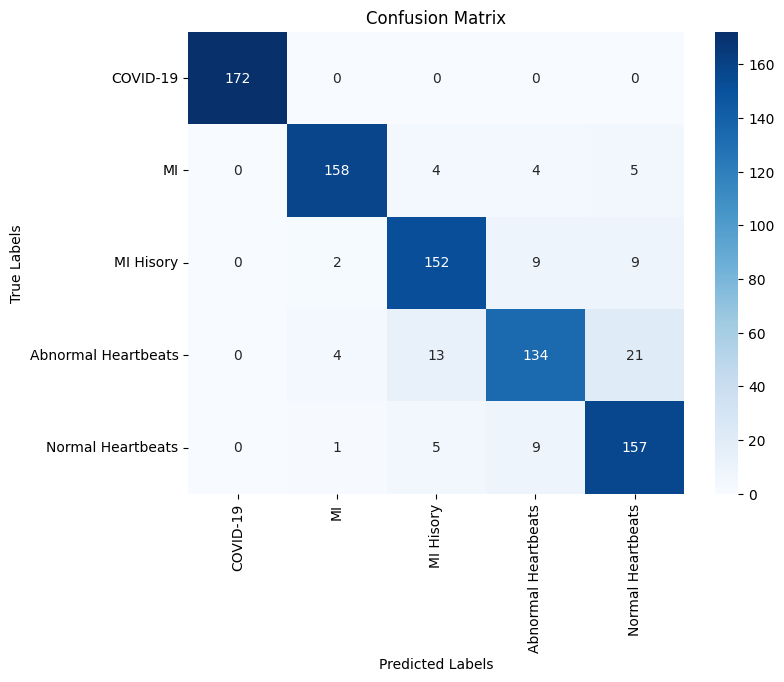

In [78]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

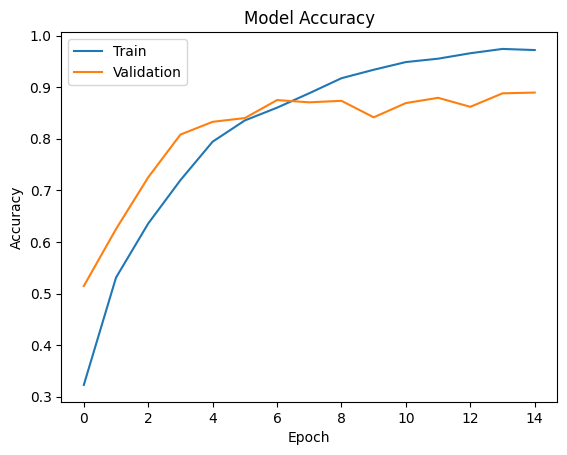

In [79]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

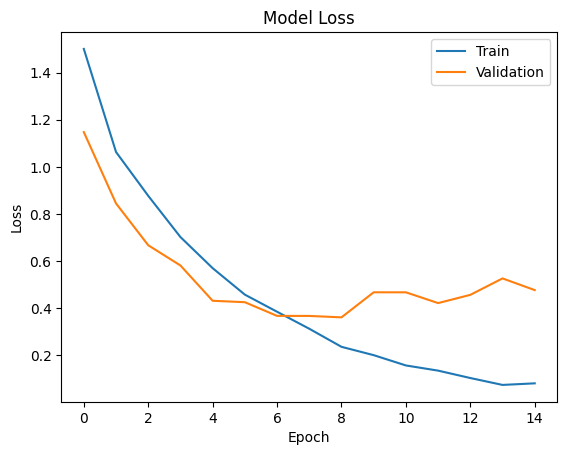

In [81]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()